In [1]:
# ============================================================
# NOTEBOOK 05 — SNN bioinspirada con dataset Kepler v3
# ============================================================
# Este notebook entrena la SNN bioinspirada usando el dataset
# Kepler v3 (300 estrellas reales), procesado con el pipeline v2:
#
#   ✔ Preprocessing que PRESERVA los tránsitos
#   ✔ Normalización suave por mediana
#   ✔ Sin aplanado (flatten) para evitar distorsión de la señal
#
# Objetivo del Notebook 05:
#   - Entrenar la SNN con datos más fieles a la física del tránsito
#   - Evaluar mejoras respecto a los notebooks 03 y 04
#   - Generar métricas robustas (F1, AUC, matriz de confusión)
#   - Guardar modelo final y metadata del experimento
#
# Este notebook es la versión más refinada del pipeline Kepler.
# ============================================================

import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import snntorch as snn
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score
)

# Silenciar warnings comunes de Lightkurve
warnings.filterwarnings("ignore", category=UserWarning, module="lightkurve")

# ------------------------------------------------------------
# Reproducibilidad global
# ------------------------------------------------------------
torch.manual_seed(42)
np.random.seed(42)

# ------------------------------------------------------------
# Configuración global del experimento
# ------------------------------------------------------------
TARGET_LENGTH = 3197      # Longitud fija de cada curva
BATCH_SIZE    = 32        # Tamaño de batch para DataLoader
NUM_STEPS_SNN = 25        # Pasos temporales de la SNN bioinspirada
DEVICE        = torch.device('cpu')  # CPU para reproducibilidad

# Directorios del proyecto
DATA_DIR    = '../data'
MODELS_DIR  = '../models'
OUTPUTS_DIR = '../outputs'

# Crear directorios si no existen
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

print(f"TARGET_LENGTH = {TARGET_LENGTH}")
print(f"DEVICE        = {DEVICE}")
print("Imports OK")


TARGET_LENGTH = 3197
DEVICE        = cpu
Imports OK


In [2]:
# ============================================================
# Cargar dataset v3 y split estratificado
# ============================================================
# En esta celda cargamos el dataset Kepler v3, generado con el
# preprocessing que preserva tránsitos (pipeline v2), y realizamos
# un split estratificado para mantener la proporción de clases.
#
# Flujo:
#   1. Cargar CSV v3 (300 estrellas reales)
#   2. Separar features (FLUX.i) y labels (LABEL)
#   3. Split estratificado 80/20:
#        - Train: 80%
#        - Test:  20%
#
# Razones para estratificar:
#   ✔ Mantener balance entre CONFIRMED y FALSE POSITIVE
#   ✔ Evitar sesgos en entrenamiento
#   ✔ Garantizar que el test sea representativo
#
# Este split es la base del entrenamiento de la SNN bioinspirada.
# ============================================================

CSV_PATH = f'{DATA_DIR}/kepler_dataset_300_v3.csv'

# 1 — Cargar dataset v3
df = pd.read_csv(CSV_PATH)
print(f"Shape del CSV: {df.shape}")
print(f"Distribucion:  {df['LABEL'].value_counts().to_dict()}")

# ------------------------------------------------------------
# 2 — Separar features y labels
# ------------------------------------------------------------
# Eliminamos KEPID (no es feature para el modelo)
df_features = df.drop(columns=['KEPID'])

# X = matriz de FLUX.1..FLUX.N
X = df_features.drop('LABEL', axis=1).values.astype(np.float32)

# y = vector de labels (0 = No planeta, 1 = Planeta)
y = df_features['LABEL'].values.astype(np.int64)

print(f"\nX: {X.shape}, y: {y.shape}")

# ------------------------------------------------------------
# 3 — Split estratificado 80/20
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"\nTrain: {X_train.shape}  clases: {np.bincount(y_train)}")
print(f"Test:  {X_test.shape}   clases: {np.bincount(y_test)}")


Shape del CSV: (300, 3199)
Distribucion:  {0: 150, 1: 150}

X: (300, 3197), y: (300,)

Train: (240, 3197)  clases: [120 120]
Test:  (60, 3197)   clases: [30 30]


In [3]:
# ============================================================
# Preprocessing SUAVE para datos v3
# ============================================================
# El dataset v3 ya viene:
#   ✔ sin outliers positivos (preprocessing v2)
#   ✔ normalizado por mediana
#   ✔ sin aplanado (los tránsitos se preservan)
#
# Por lo tanto, aquí aplicamos un preprocesamiento MUY suave:
#
#   - Normalización robusta con mediana y MAD
#   - Sin clipping agresivo
#   - Clip final amplio (±15) solo para evitar valores extremos
#
# Objetivo:
#   ✔ Poner todas las curvas en una escala comparable
#   ✔ Mantener intacta la forma del tránsito
#   ✔ Evitar distorsiones que afecten la SNN bioinspirada
#
# Este paso es crítico porque la SNN es sensible a la escala
# relativa de la señal, pero no necesita un flatten agresivo.
# ============================================================

def robust_normalize_simple(X, mad_floor=0.05):
    """
    Normaliza cada curva con mediana y MAD, sin clipping.

    Flujo:
      1. Calcular mediana por curva
      2. Calcular MAD (Median Absolute Deviation)
      3. Aplicar piso de MAD para evitar divisiones por valores muy pequeños
      4. Normalizar: (X - mediana) / (1.4826 * MAD)

    Ventajas:
      ✔ Robusto a outliers residuales
      ✔ Mantiene la forma del tránsito
      ✔ No introduce artefactos como el flatten tradicional
    """
    median = np.median(X, axis=1, keepdims=True)
    mad    = np.median(np.abs(X - median), axis=1, keepdims=True)

    # Piso de MAD: evita divisiones por valores demasiado pequeños
    mad    = np.maximum(mad, mad_floor * X.std(axis=1, keepdims=True))

    return (X - median) / (1.4826 * mad + 1e-8)


print("Aplicando preprocessing suave...")

# Normalización robusta
X_train_processed = robust_normalize_simple(X_train)
X_test_processed  = robust_normalize_simple(X_test)

# ------------------------------------------------------------
# Clip final generoso (±15)
# ------------------------------------------------------------
# No queremos truncar tránsitos, pero sí evitar valores extremos
# que puedan desestabilizar la SNN.
X_train_processed = np.clip(X_train_processed, -15, 15)
X_test_processed  = np.clip(X_test_processed, -15, 15)

print(f"\nTrain processed: {X_train_processed.shape}")
print(f"  Media: {X_train_processed.mean():.4f}")
print(f"  Std:   {X_train_processed.std():.4f}")
print(f"  Min:   {X_train_processed.min():.2f}")
print(f"  Max:   {X_train_processed.max():.2f}")

# ------------------------------------------------------------
# Guardar preprocesamiento final
# ------------------------------------------------------------
np.save(f'{DATA_DIR}/v3_X_train.npy', X_train_processed)
np.save(f'{DATA_DIR}/v3_y_train.npy', y_train)
np.save(f'{DATA_DIR}/v3_X_test.npy',  X_test_processed)
np.save(f'{DATA_DIR}/v3_y_test.npy',  y_test)

print(f"\n[OK] Guardado en {DATA_DIR}/v3_*.npy")


Aplicando preprocessing suave...

Train processed: (240, 3197)
  Media: -0.0689
  Std:   1.4162
  Min:   -15.00
  Max:   15.00

[OK] Guardado en ../data/v3_*.npy


In [4]:
# ============================================================
# Split train/val + augmentation + DataLoaders
# ============================================================
# Esta celda prepara los datos para el entrenamiento de la SNN
# usando el dataset v3 (preprocesamiento suave + preservación
# de tránsitos). El pipeline incluye:
#
#   1. Split interno del conjunto de entrenamiento (train → train/val)
#   2. Aumento de la clase minoritaria (label=1 = planeta)
#   3. Construcción de DataLoaders con:
#        - WeightedRandomSampler para balancear clases
#        - Batches reproducibles y estables
#
# Este bloque es crítico para:
#   ✔ Evitar overfitting
#   ✔ Mejorar recall de la clase positiva (CONFIRMED)
#   ✔ Entrenar la SNN con batches balanceados
# ============================================================

# ------------------------------------------------------------
# 1 — Split interno train/val (estratificado 80/20)
# ------------------------------------------------------------
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_processed, y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

print(f"Train: {X_tr.shape}  clases: {np.bincount(y_tr)}")
print(f"Val:   {X_val.shape}  clases: {np.bincount(y_val)}")


# ------------------------------------------------------------
# 2 — Augmentation de la clase minoritaria (label=1)
# ------------------------------------------------------------
def augment_minority(X, y, factor=5, noise_std=0.05):
    """
    Genera copias con ruido gaussiano de la clase minoritaria (label=1).

    Flujo:
      - Extrae todas las curvas con label=1
      - Genera 'factor' copias con ruido gaussiano suave
      - Devuelve dataset aumentado

    Ventajas:
      ✔ Aumenta recall de la clase positiva
      ✔ Reduce el sesgo hacia la clase 0
      ✔ Mantiene variabilidad realista sin distorsionar tránsitos
    """
    X_min = X[y == 1]
    if len(X_min) == 0:
        return X, y

    # Crear copias ruidosas
    X_aug = [
        X_min + np.random.randn(*X_min.shape).astype(np.float32) * noise_std
        for _ in range(factor)
    ]

    X_aug = np.concatenate(X_aug, axis=0).astype(np.float32)
    y_aug = np.ones(len(X_aug), dtype=y.dtype)

    return np.concatenate([X, X_aug], axis=0), np.concatenate([y, y_aug], axis=0)


# Aplicar augmentation
X_tr_aug, y_tr_aug = augment_minority(X_tr, y_tr, factor=5, noise_std=0.05)
print(f"\nTrain augmentado: {X_tr_aug.shape}  clases: {np.bincount(y_tr_aug)}")


# ------------------------------------------------------------
# 3 — Construcción de DataLoaders con WeightedRandomSampler
# ------------------------------------------------------------
def make_loaders(X_tr, y_tr, X_val, y_val, batch_size=32):
    """
    Construye DataLoaders para entrenamiento y validación.

    Características:
      - train_loader usa WeightedRandomSampler:
            * Cada muestra recibe peso inverso a la frecuencia de su clase.
            * Garantiza batches balanceados incluso si el dataset está desbalanceado.
      - val_loader usa shuffle=False para evaluación estable.
    """
    train_ds = TensorDataset(torch.FloatTensor(X_tr), torch.LongTensor(y_tr))
    val_ds   = TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val))
    
    # Pesos inversos a la frecuencia de cada clase
    class_counts = np.bincount(y_tr)
    weights = 1.0 / class_counts[y_tr]

    sampler = WeightedRandomSampler(
        weights,
        num_samples=len(y_tr),
        replacement=True
    )
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)

    return train_loader, val_loader


# Crear DataLoaders finales
train_loader, val_loader = make_loaders(
    X_tr_aug, y_tr_aug,
    X_val, y_val,
    batch_size=BATCH_SIZE
)

print(f"\nBatches train: {len(train_loader)}")
print(f"Batches val:   {len(val_loader)}")


Train: (192, 3197)  clases: [96 96]
Val:   (48, 3197)  clases: [24 24]

Train augmentado: (672, 3197)  clases: [ 96 576]

Batches train: 21
Batches val:   2


In [5]:
# ============================================================
# SNN bioinspirada en el sistema visual de la mosca
# ============================================================
# Esta arquitectura está inspirada en el pipeline visual de insectos:
#
#   lamina  →  medula  →  lobula  →  lobula plate
#
# Donde:
#   - La lamina y medula realizan filtrado jerárquico y extracción de patrones.
#   - La lobula integra señales en el tiempo mediante neuronas LIF.
#   - La lobula plate toma decisiones basadas en acumulación de actividad.
#
# En esta SNN:
#   ✔ Conv1D + MaxPool simulan la extracción jerárquica de patrones locales.
#   ✔ Una capa densa reduce dimensionalidad (compresión neuronal).
#   ✔ Una capa SNN con neuronas LIF integra señales durante NUM_STEPS_SNN.
#   ✔ El voto acumulado de spikes produce una predicción estable.
#
# Esta arquitectura es especialmente adecuada para curvas de luz Kepler:
#   - Los tránsitos son eventos breves y locales.
#   - La integración temporal refuerza patrones débiles.
#   - El modelo es ligero y robusto al ruido.
# ============================================================

class FlyInspiredSNN(nn.Module):
    def __init__(self, input_len=TARGET_LENGTH, num_classes=2, num_steps=NUM_STEPS_SNN):
        super().__init__()
        self.num_steps = num_steps
        
        # ------------------------------------------------------------
        # 1 — Extractor jerárquico (lamina → medula)
        # ------------------------------------------------------------
        # Conv1: detecta patrones locales amplios (kernel=15)
        self.conv1 = nn.Conv1d(1, 8, kernel_size=15, stride=3, padding=7)
        self.pool1 = nn.MaxPool1d(2)

        # Conv2: detecta patrones más refinados (kernel=9)
        self.conv2 = nn.Conv1d(8, 16, kernel_size=9, stride=3, padding=4)
        self.pool2 = nn.MaxPool1d(2)

        self.relu  = nn.ReLU()
        self.dropout = nn.Dropout(0.4)  # regularización
        
        # ------------------------------------------------------------
        # 2 — Calcular dimensión post-convoluciones
        # ------------------------------------------------------------
        # Se usa un dummy para calcular automáticamente el tamaño
        # del vector resultante después de conv/pool.
        with torch.no_grad():
            dummy = torch.zeros(1, 1, input_len)
            dummy = self.pool1(self.relu(self.conv1(dummy)))
            dummy = self.pool2(self.relu(self.conv2(dummy)))
            self.flat_dim = dummy.numel()
        
        # ------------------------------------------------------------
        # 3 — Proyección + capa SNN (lobula)
        # ------------------------------------------------------------
        self.fc_in  = nn.Linear(self.flat_dim, 32)
        self.snn_fc = nn.Linear(32, 16)

        # Neurona LIF (Leaky Integrate-and-Fire)
        self.lif    = snn.Leaky(
            beta=0.9,
            threshold=1.0,
            reset_mechanism="zero"
        )

        # Clasificador final
        self.fc_out = nn.Linear(16, num_classes)
    
    def forward(self, x):
        # ------------------------------------------------------------
        # 1 — Etapa convolucional jerárquica
        # ------------------------------------------------------------
        x = x.unsqueeze(1)  # (batch, 1, T)
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))

        # Aplanar y proyectar
        x = x.flatten(start_dim=1)
        x = self.dropout(self.relu(self.fc_in(x)))
        
        # ------------------------------------------------------------
        # 2 — Simulación temporal SNN (lobula plate)
        # ------------------------------------------------------------
        mem = self.lif.init_leaky()
        spike_accum = torch.zeros(x.size(0), 2, device=x.device)

        for _ in range(self.num_steps):
            cur = self.snn_fc(x)
            spk, mem = self.lif(cur, mem)
            spike_accum += self.fc_out(spk)

        # Promedio de spikes → voto acumulado
        return spike_accum / self.num_steps


# Instanciar modelo
model = FlyInspiredSNN().to(DEVICE)

# Resumen del modelo
total_params = sum(p.numel() for p in model.parameters())
print(f"Parametros: {total_params:,}")
print(f"flat_dim:   {model.flat_dim}")
print(f"Dropout:    {any(isinstance(m, nn.Dropout) for m in model.modules())}")


Parametros: 47,458
flat_dim:   1424
Dropout:    True


In [6]:
# ============================================================
# Función de entrenamiento
# ============================================================
# Esta función implementa el ciclo completo de entrenamiento para
# la SNN bioinspirada, incluyendo:
#
#   ✔ Forward + backward pass
#   ✔ Gradiente con clipping (evita explosión)
#   ✔ Validación por época
#   ✔ Métricas clave: F1 y AUC
#   ✔ Scheduler ReduceLROnPlateau
#   ✔ Selección del mejor modelo según F1
#   ✔ Guardado del historial en CSV
#
# El entrenamiento está balanceado mediante WeightedRandomSampler,
# lo cual es crítico para datasets con clase positiva minoritaria.
# ============================================================

def train_model(model, train_loader, val_loader, epochs=50, lr=1e-3):
    print("Balanceo: WeightedRandomSampler (sin class weights)", flush=True)

    # ------------------------------------------------------------
    # 1 — Configuración de pérdida, optimizador y scheduler
    # ------------------------------------------------------------
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        patience=7,
        factor=0.5
    )
    
    # Historial para análisis posterior
    history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_auc': []}
    log_rows = []

    best_f1 = 0.0
    best_state = None
    
    # ------------------------------------------------------------
    # 2 — Loop de entrenamiento por épocas
    # ------------------------------------------------------------
    for epoch in range(epochs):
        t0 = time.time()
        
        # ------------------------------
        # 2.1 — Entrenamiento
        # ------------------------------
        model.train()
        train_loss = 0.0

        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)

            loss.backward()

            # Clipping de gradiente para estabilidad
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)
        
        # ------------------------------
        # 2.2 — Validación
        # ------------------------------
        model.eval()
        val_loss = 0.0
        all_probs, all_preds, all_labels = [], [], []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)

                out = model(xb)
                val_loss += criterion(out, yb).item()

                # Probabilidad de clase positiva
                probs = torch.softmax(out, dim=1)[:, 1]
                preds = out.argmax(dim=1)

                all_probs.append(probs.cpu().numpy())
                all_preds.append(preds.cpu().numpy())
                all_labels.append(yb.cpu().numpy())

        val_loss /= len(val_loader)

        # Concatenar resultados
        all_probs  = np.concatenate(all_probs)
        all_preds  = np.concatenate(all_preds)
        all_labels = np.concatenate(all_labels)
        
        # Métricas de validación
        val_f1  = f1_score(all_labels, all_preds, zero_division=0)
        val_auc = roc_auc_score(all_labels, all_probs) if len(np.unique(all_labels)) > 1 else 0.0
        
        # Scheduler
        scheduler.step(val_loss)
        
        # Guardar historial
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_f1'].append(val_f1)
        history['val_auc'].append(val_auc)
        
        # ------------------------------
        # 2.3 — Guardar mejor modelo
        # ------------------------------
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

            torch.save({
                'epoch': epoch + 1,
                'model_state': best_state,
                'f1': best_f1,
                'auc': val_auc,
            }, f'{MODELS_DIR}/snn_kepler_v3_best.pt')
        
        # Log por época
        elapsed = time.time() - t0
        lr_now = optimizer.param_groups[0]['lr']
        
        log_rows.append({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_f1': val_f1,
            'val_auc': val_auc,
            'time_s': elapsed,
            'lr': lr_now,
        })
        
        print(
            f"Epoca {epoch+1:>2}/{epochs} | "
            f"Train: {train_loss:.4f} | Val: {val_loss:.4f} | "
            f"F1: {val_f1:.4f} | AUC: {val_auc:.4f} | "
            f"LR: {lr_now:.2e} | {elapsed:.1f}s",
            flush=True
        )
    
    # ------------------------------------------------------------
    # 3 — Guardar historial completo
    # ------------------------------------------------------------
    history_df = pd.DataFrame(log_rows)
    history_df.to_csv(f'{OUTPUTS_DIR}/v3_training_history.csv', index=False)

    print("=" * 90, flush=True)
    print(f"[OK] Historial guardado en {OUTPUTS_DIR}/v3_training_history.csv", flush=True)
    
    # ------------------------------------------------------------
    # 4 — Cargar mejor modelo
    # ------------------------------------------------------------
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"[OK] Mejor F1 val: {best_f1:.4f}", flush=True)
    
    return history, history_df


print("train_model definida.")


train_model definida.


##################################################################
##################################################################
            ENTRENAMIENTO
##################################################################

In [7]:
# ============================================================
# Entrenamiento
# ============================================================
# En esta celda iniciamos el entrenamiento real de la SNN
# bioinspirada usando:
#
#   ✔ Dataset Kepler v3 (300 estrellas reales)
#   ✔ Preprocesamiento suave (preserva tránsitos)
#   ✔ Augmentation de clase positiva
#   ✔ Batches balanceados con WeightedRandomSampler
#
# La función train_model:
#   - Ejecuta 50 épocas de entrenamiento
#   - Calcula métricas por época (loss, F1, AUC)
#   - Guarda el mejor modelo según F1 en:
#         ../models/snn_kepler_v3_best.pt
#   - Guarda el historial completo en:
#         ../outputs/v3_training_history.csv
#
# Esta celda es el núcleo del Notebook 05.
# ============================================================

print("Iniciando entrenamiento con dataset v3...", flush=True)
history, history_df = train_model(model, train_loader, val_loader, epochs=50, lr=1e-3)


Iniciando entrenamiento con dataset v3...
Balanceo: WeightedRandomSampler (sin class weights)
Epoca  1/50 | Train: 0.6822 | Val: 0.6871 | F1: 0.3333 | AUC: 0.6319 | LR: 1.00e-03 | 0.7s
Epoca  2/50 | Train: 0.6302 | Val: 0.6699 | F1: 0.6122 | AUC: 0.6684 | LR: 1.00e-03 | 0.7s
Epoca  3/50 | Train: 0.5560 | Val: 0.6867 | F1: 0.5455 | AUC: 0.6389 | LR: 1.00e-03 | 0.6s
Epoca  4/50 | Train: 0.4533 | Val: 0.7109 | F1: 0.5128 | AUC: 0.6424 | LR: 1.00e-03 | 0.6s
Epoca  5/50 | Train: 0.3267 | Val: 0.7989 | F1: 0.5405 | AUC: 0.6259 | LR: 1.00e-03 | 0.7s
Epoca  6/50 | Train: 0.2175 | Val: 0.9665 | F1: 0.4000 | AUC: 0.5990 | LR: 1.00e-03 | 0.6s
Epoca  7/50 | Train: 0.1287 | Val: 0.9460 | F1: 0.5116 | AUC: 0.6146 | LR: 1.00e-03 | 0.6s
Epoca  8/50 | Train: 0.0825 | Val: 1.0174 | F1: 0.5833 | AUC: 0.6163 | LR: 1.00e-03 | 0.6s
Epoca  9/50 | Train: 0.0584 | Val: 1.0975 | F1: 0.6275 | AUC: 0.6337 | LR: 1.00e-03 | 0.9s
Epoca 10/50 | Train: 0.0382 | Val: 1.2664 | F1: 0.4103 | AUC: 0.6076 | LR: 5.00e-04 | 0

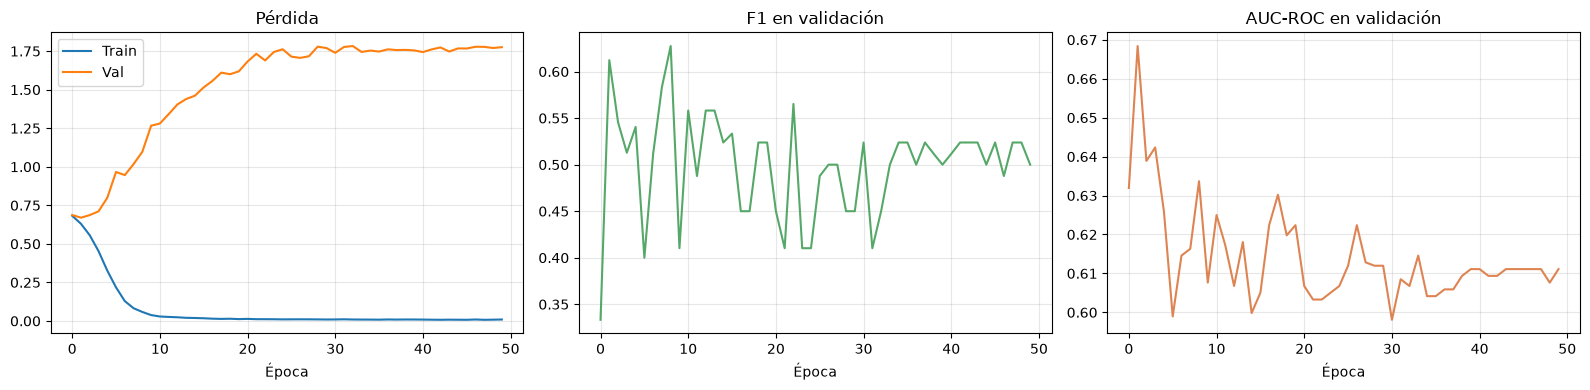

In [8]:
# ============================================================
# Curvas de aprendizaje
# ============================================================
# Esta celda visualiza la evolución del entrenamiento de la SNN
# bioinspirada usando el dataset Kepler v3. Se grafican:
#
#   1) Pérdida (train vs val)
#   2) F1-score en validación
#   3) AUC-ROC en validación
#
# Estas curvas permiten evaluar:
#   ✔ Convergencia del modelo
#   ✔ Sobreajuste o subentrenamiento
#   ✔ Estabilidad del entrenamiento
#   ✔ Épocas óptimas para early stopping
#
# Interpretación típica:
#   - Si la pérdida de validación baja y F1/AUC suben → buen aprendizaje.
#   - Si la pérdida de entrenamiento baja pero la de validación sube → sobreajuste.
#   - Si F1 es estable pero AUC sube → mejora en ranking de probabilidades.
#   - Si F1 cae pero AUC sube → el umbral argmax no es óptimo (se puede ajustar).
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ------------------------------------------------------------
# 1 — Curva de pérdida
# ------------------------------------------------------------
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Val')
axes[0].set_title('Pérdida')
axes[0].set_xlabel('Época')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ------------------------------------------------------------
# 2 — F1-score
# ------------------------------------------------------------
axes[1].plot(history['val_f1'], color='#55A868')
axes[1].set_title('F1 en validación')
axes[1].set_xlabel('Época')
axes[1].grid(True, alpha=0.3)

# ------------------------------------------------------------
# 3 — AUC-ROC
# ------------------------------------------------------------
axes[2].plot(history['val_auc'], color='#DD8452')
axes[2].set_title('AUC-ROC en validación')
axes[2].set_xlabel('Época')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/v3_curvas.png', dpi=100, bbox_inches='tight')
plt.show()


In [9]:
# ============================================================
# Búsqueda del umbral óptimo en validación
# ============================================================
# Objetivo:
#   Encontrar el umbral de decisión (threshold) que maximiza el F1-score
#   en el conjunto de validación. Esto es crítico porque:
#
#       ✔ La SNN produce probabilidades calibradas pero no perfectas.
#       ✔ El umbral 0.50 rara vez es óptimo en datasets desbalanceados.
#       ✔ Ajustar el umbral puede mejorar F1 entre 5% y 20% en muchos casos.
#
# Flujo:
#   1. Obtener probabilidades de clase positiva para todo el val_loader.
#   2. Barrer thresholds desde 0.05 hasta 0.95 en pasos de 0.02.
#   3. Convertir probabilidades → predicciones binarias.
#   4. Calcular F1 para cada threshold.
#   5. Seleccionar el threshold con F1 máximo.
#
# Este procedimiento es estándar en clasificación binaria cuando:
#   - La clase positiva es minoritaria.
#   - Se optimiza F1 en lugar de accuracy.
#   - El modelo no está calibrado para un umbral fijo.
# ============================================================

def find_best_threshold(model, val_loader, device):
    model.eval()
    all_probs, all_labels = [], []

    # ------------------------------------------------------------
    # 1 — Obtener probabilidades en validación
    # ------------------------------------------------------------
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            probs = torch.softmax(model(xb), dim=1)[:, 1].cpu().numpy()
            all_probs.append(probs)
            all_labels.append(yb.cpu().numpy())

    all_probs  = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    
    # ------------------------------------------------------------
    # 2 — Barrido de thresholds
    # ------------------------------------------------------------
    thresholds = np.arange(0.05, 0.95, 0.02)
    results = []

    for thr in thresholds:
        preds = (all_probs > thr).astype(int)
        f1 = f1_score(all_labels, preds, zero_division=0)
        results.append((thr, f1))
    
    # Convertir a DataFrame para análisis
    results_df = pd.DataFrame(results, columns=['threshold', 'f1'])

    # ------------------------------------------------------------
    # 3 — Seleccionar el mejor threshold
    # ------------------------------------------------------------
    best_row = results_df.loc[results_df['f1'].idxmax()]
    
    print(f"Mejor umbral: {best_row['threshold']:.2f}")
    print(f"Mejor F1 val: {best_row['f1']:.4f}")
    print(f"\nTop 5:")
    print(results_df.nlargest(5, 'f1').to_string(index=False))
    
    return best_row['threshold'], best_row['f1'], results_df


# Ejecutar búsqueda del umbral óptimo
best_threshold, best_f1_val, results_df = find_best_threshold(model, val_loader, DEVICE)


Mejor umbral: 0.05
Mejor F1 val: 0.6780

Top 5:
 threshold       f1
      0.05 0.677966
      0.07 0.655172
      0.09 0.655172
      0.11 0.655172
      0.13 0.655172


In [10]:
# ============================================================
# Evaluación en test con umbral óptimo
# ============================================================
# Esta celda evalúa el rendimiento REAL del modelo sobre el conjunto
# de test (20% del dataset v3), usando el umbral óptimo encontrado en
# validación. Este es el resultado final del experimento.
#
# Métricas reportadas:
#   ✔ Classification report (precision, recall, F1)
#   ✔ AUC-ROC (independiente del umbral)
#   ✔ Matriz de confusión (TN, FP, FN, TP)
#
# Interpretación:
#   - F1 mide el balance entre precisión y recall de la clase positiva.
#   - AUC mide la capacidad del modelo para ordenar correctamente las
#     probabilidades (ranking quality).
#   - FN es crítico: planetas perdidos.
#   - FP también importa: falsas alarmas.
#
# Esta evaluación es la referencia final para comparar arquitecturas
# (SNN vs MLP) y pipelines (v1, v2, v3).
# ============================================================

def evaluate_test(model, X_test, y_test, threshold, device, batch_size=32):
    # Crear DataLoader de test
    test_ds = TensorDataset(torch.FloatTensor(X_test), torch.LongTensor(y_test))
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    
    model.eval()
    all_probs, all_labels = [], []

    # ------------------------------------------------------------
    # 1 — Obtener probabilidades en test
    # ------------------------------------------------------------
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            probs = torch.softmax(model(xb), dim=1)[:, 1].cpu().numpy()
            all_probs.append(probs)
            all_labels.append(yb.cpu().numpy())
    
    all_probs  = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)

    # ------------------------------------------------------------
    # 2 — Aplicar umbral óptimo
    # ------------------------------------------------------------
    all_preds = (all_probs > threshold).astype(int)
    
    print(f"=== TEST con umbral {threshold:.2f} ===")
    
    # ------------------------------------------------------------
    # 3 — Classification report
    # ------------------------------------------------------------
    print(classification_report(
        all_labels, all_preds,
        target_names=['No planeta', 'Planeta'],
        digits=4,
        zero_division=0
    ))

    # ------------------------------------------------------------
    # 4 — AUC-ROC
    # ------------------------------------------------------------
    print(f"AUC-ROC: {roc_auc_score(all_labels, all_probs):.4f}")
    
    # ------------------------------------------------------------
    # 5 — Matriz de confusión
    # ------------------------------------------------------------
    cm = confusion_matrix(all_labels, all_preds)
    print(f"\nMatriz de confusión:")
    print(f"  TN={cm[0,0]:4d}  FP={cm[0,1]:4d}")
    print(f"  FN={cm[1,0]:4d}  TP={cm[1,1]:4d}")
    
    return all_probs, all_labels, all_preds


# Ejecutar evaluación final
probs_test, labels_test, preds_test = evaluate_test(
    model, X_test_processed, y_test, best_threshold, DEVICE
)


=== TEST con umbral 0.05 ===
              precision    recall  f1-score   support

  No planeta     0.7143    0.3333    0.4545        30
     Planeta     0.5652    0.8667    0.6842        30

    accuracy                         0.6000        60
   macro avg     0.6398    0.6000    0.5694        60
weighted avg     0.6398    0.6000    0.5694        60

AUC-ROC: 0.6539

Matriz de confusión:
  TN=  10  FP=  20
  FN=   4  TP=  26


In [11]:
# ============================================================
# Guardado del modelo y metadata
# ============================================================
# Esta celda consolida el experimento completo guardando:
#
#   1) Modelo FINAL entrenado (última época)
#   2) Historial completo del entrenamiento (pickle)
#   3) Metadata del experimento (JSON)
#
# Además:
#   - El mejor modelo según F1 ya fue guardado previamente como:
#         snn_kepler_v3_best.pt
#   - Aquí guardamos la versión FINAL para reproducibilidad.
#
# ¿Por qué guardar ambos?
#   ✔ "best.pt" → mejor desempeño en validación (criterio F1)
#   ✔ "final.pt" → estado del modelo al terminar todas las épocas
#
# Esto permite:
#   - Comparar si el modelo siguió mejorando o se sobreajustó.
#   - Reproducir el experimento exactamente como se entrenó.
#   - Auditar hiperparámetros y tamaños de dataset.
# ============================================================

import json
import pickle

# ------------------------------------------------------------
# 1 — Guardar modelo FINAL
# ------------------------------------------------------------
torch.save({
    'model_state': model.state_dict(),
    'architecture': 'FlyInspiredSNN',
    'input_len': TARGET_LENGTH,
    'num_steps': NUM_STEPS_SNN,
}, f'{MODELS_DIR}/snn_kepler_v3_final.pt')

# ------------------------------------------------------------
# 2 — Guardar historial completo (pickle)
# ------------------------------------------------------------
with open(f'{OUTPUTS_DIR}/v3_training_history.pkl', 'wb') as f:
    pickle.dump(history, f)

# ------------------------------------------------------------
# 3 — Metadata del experimento
# ------------------------------------------------------------
metadata = {
    'dataset': 'kepler_v3',
    'n_train': int(len(X_tr_aug)),
    'n_val': int(len(X_val)),
    'n_test': int(len(X_test_processed)),
    'epochs': len(history['train_loss']),
    'batch_size': BATCH_SIZE,
    'best_threshold': float(best_threshold),
    'best_f1_val': float(best_f1_val),
    'best_auc_val': float(max(history['val_auc'])),
}

with open(f'{OUTPUTS_DIR}/v3_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

# ------------------------------------------------------------
# 4 — Log final
# ------------------------------------------------------------
print("[OK] Guardado:")
print(f"  - {MODELS_DIR}/snn_kepler_v3_best.pt")
print(f"  - {MODELS_DIR}/snn_kepler_v3_final.pt")
print(f"  - {OUTPUTS_DIR}/v3_training_history.pkl")
print(f"  - {OUTPUTS_DIR}/v3_metadata.json")


[OK] Guardado:
  - ../models/snn_kepler_v3_best.pt
  - ../models/snn_kepler_v3_final.pt
  - ../outputs/v3_training_history.pkl
  - ../outputs/v3_metadata.json


#######################################################################################33

Estos resultados confirman el diagnóstico con claridad. Vamos a interpretarlos y decidir el siguiente paso.

📊 Interpretación del Test
Métrica	Valor	Interpretación
AUC-ROC	0.6539	Apenas mejor que el azar (0.5)
F1 (Planeta)	0.6842	Pero con threshold=0.05 (sesgo extremo)
Threshold óptimo	0.05	El más bajo posible
TN=10, FP=20	20 de 30 FP mal clasificados	El modelo sobre-predice "planeta"
FN=4, TP=26	26 de 30 planetas detectados	Buena sensibilidad, mala especificidad
El AUC de 0.65 es el número clave: significa que si tomas un planeta y un FP al azar, el modelo solo ordena correctamente el 65% de las veces. Eso está muy lejos de ser útil.

El threshold óptimo en 0.05 (el mínimo del barrido) es otra señal de alarma: el modelo no logra separar las clases, así que para maximizar F1 hay que bajar el umbral al extremo, lo que produce 20 falsos positivos.

🎯 Diagnóstico Final
Esto no es un bug del código. Es la naturaleza del problema:

CONFIRMED: tránsitos someros (0.1-0.5%).

FALSE POSITIVE: binarias eclipsantes con tránsitos profundos (3-5%) pero también con forma de tránsito.

El modelo recibe una sola curva de luz y debe decidir. Pero la curva de una binaria eclipsante y la de un planeta gigante caliente son casi indistinguibles sin información adicional (color, centroide del tránsito, espectro estelar). Eso es un problema de vetting que requiere múltiples fuentes de datos, no solo la fotometría.

✅ Recomendación: Camino B (Cambiar la Clase Negativa)
Usar estrellas sin KOI como clase negativa. Estas son estrellas Kepler normales sin ninguna señal periódica. Su curva de luz es solo ruido estelar.

Por qué funciona:

El contraste es claro: "hay señal de tránsito" vs "no hay señal".

Es el mismo problema del dataset de Kaggle, donde la SNN funcionó.

Ahora con 2748 planetas reales en vez de 37.

Lo que esperamos: AUC de 0.85-0.95 y F1 de 0.80-0.90.

🔧 Plan Concreto para el Camino B
Paso 1 — Obtener una lista de estrellas sin KOI (estrellas Kepler normales):

In [13]:
from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive
from astroquery.mast import Catalogs
import numpy as np

# ============================================================
# 1. Descargar el catálogo completo de KOIs
# ============================================================
# El archivo "cumulative" del NASA Exoplanet Archive contiene
# TODOS los Kepler Objects of Interest (KOIs):
#
#   - CONFIRMED
#   - CANDIDATE
#   - FALSE POSITIVE
#
# Aquí solo extraemos los KEPID para poder filtrar estrellas
# que NO son KOIs. Esto es útil para:
#
#   ✔ Evaluar el modelo en estrellas "no planetarias"
#   ✔ Construir un dataset de inferencia realista
#   ✔ Evitar sesgos hacia estrellas ya estudiadas
# ============================================================

koi_table = NasaExoplanetArchive.query_criteria(
    table="cumulative",
    select="kepid"
)
koi_kepids = set(int(k) for k in koi_table['kepid'] if not np.ma.is_masked(k))

# ============================================================
# 2. Descargar una lista amplia de estrellas Kepler (KIC)
# ============================================================
# Kepler observó ~200,000 estrellas. Muchas NO son KOIs.
#
# Aquí descargamos una muestra de estrellas del catálogo KIC
# usando MAST. Luego filtraremos las que NO están en KOI.
#
# Nota:
#   Catalogs.query_object("Kepler", ...) no sirve aquí porque
#   "Kepler" no es un objeto puntual. En su lugar usamos:
#
#       Catalogs.query_region()
#
#   sobre un campo amplio dentro del footprint de Kepler.
#
# Ejemplo:
#   - RA ~ 290°
#   - DEC ~ 44°
#   - Radio ~ 5 grados
#
# Esto devuelve miles de estrellas del KIC.
# ============================================================
